<a href="https://colab.research.google.com/github/atilimai/pneumonia-xray-ai/blob/main/notebooks/colab_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab Training Notebook

This notebook trains the Pneumonia Detection model in Google Colab using the Kaggle chest X-ray dataset.

The notebook is designed to run in a fresh Colab session with minimal manual steps:

1. Upload `kaggle.json`
2. Download the dataset from Kaggle
3. Load project configuration files
4. Train the selected model
5. Save checkpoints and training figures

This notebook uses configuration files under `configs/` to avoid hardcoding hyperparameters.

In [1]:
# Clone repository and move into project root

import os

REPO_URL = "https://github.com/atilimai/pneumonia-xray-ai.git"
REPO_DIR = "pneumonia-xray-ai"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}

%cd {REPO_DIR}

Cloning into 'pneumonia-xray-ai'...
remote: Enumerating objects: 423, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 423 (delta 74), reused 26 (delta 13), pack-reused 282 (from 1)
Receiving objects: 100% (423/423), 6.22 MiB | 18.83 MiB/s, done.
Resolving deltas: 100% (191/191), done.
/content/pneumonia-xray-ai


In [2]:
# Install required dependencies

!pip install -q kaggle timm pyyaml scikit-learn matplotlib pandas tqdm

In [3]:
# Imports

import os
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## Kaggle Dataset Access

This notebook downloads the dataset directly from Kaggle using `kaggle.json`.

Before running the next cell, make sure you have downloaded `kaggle.json` from your Kaggle account:

Kaggle → Account → Create New API Token

Upload `kaggle.json` when prompted.

In [4]:
# Kaggle API setup using API token

import os
import getpass

if "KAGGLE_API_TOKEN" not in os.environ:
    token = getpass.getpass("Paste your Kaggle API token here: ")
    os.environ["KAGGLE_API_TOKEN"] = token

os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write(os.environ["KAGGLE_API_TOKEN"])

!chmod 600 /root/.kaggle/access_token

print("Kaggle API token is ready for this Colab session.")

Paste your Kaggle API token here: ··········
Kaggle API token is ready for this Colab session.


In [5]:
# Download and extract Kaggle dataset

DATA_RAW_DIR = Path("data/raw")
DATASET_DIR = DATA_RAW_DIR / "chest_xray"
ZIP_PATH = DATA_RAW_DIR / "chest-xray-pneumonia.zip"

DATA_RAW_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_DIR.exists():
    print("Downloading dataset from Kaggle...")
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p data/raw

    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_RAW_DIR)
else:
    print("Dataset already exists.")

print("Dataset path:", DATASET_DIR)
print("Exists:", DATASET_DIR.exists())

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:09<00:00, 35.7MB/s]

Extracting dataset...
Dataset path: data/raw/chest_xray
Exists: True


In [6]:
# Verify expected dataset folders

expected_paths = [
    DATASET_DIR / "train" / "NORMAL",
    DATASET_DIR / "train" / "PNEUMONIA",
    DATASET_DIR / "val" / "NORMAL",
    DATASET_DIR / "val" / "PNEUMONIA",
    DATASET_DIR / "test" / "NORMAL",
    DATASET_DIR / "test" / "PNEUMONIA",
]

for path in expected_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing expected dataset folder: {path}")

print("All expected dataset folders exist.")

All expected dataset folders exist.


In [7]:
# Load YAML configuration files

def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

MODEL_CONFIG_PATH = "configs/model/base.yaml"
TRAINING_CONFIG_PATH = "configs/training/base.yaml"
EVALUATION_CONFIG_PATH = "configs/evaluation/base.yaml"

model_config = load_yaml(MODEL_CONFIG_PATH)
training_config = load_yaml(TRAINING_CONFIG_PATH)
evaluation_config = load_yaml(EVALUATION_CONFIG_PATH)

print("Model config loaded:")
print(model_config)

print("\nTraining config loaded.")
print("Evaluation config loaded.")

Model config loaded:
{'name': 'tf_efficientnetv2_s', 'library': 'timm', 'pretrained': True, 'num_classes': 1, 'input_channels': 3, 'image_size': [224, 224], 'pooling': 'avg', 'dropout_rate': 0.0, 'freeze_backbone': False, 'head_type': 'linear', 'checkpoint_path': None, 'notes': 'Placeholder base model config for binary pneumonia classification using timm. EfficientNetV2-S is selected as the recommended starting model, with EfficientNet-B0 as a fallback if Colab memory or runtime becomes an issue.'}

Training config loaded.
Evaluation config loaded.


In [8]:
# Reproducibility setup

seed = training_config.get("seed", 42)

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to: {seed}")

Random seed set to: 42


In [9]:
# Runtime mode

FAST_DEV_RUN = True

# FAST_DEV_RUN = True:
# - uses a small subset of images
# - runs for 1 epoch
# - verifies the notebook can run end-to-end in Colab
#
# For full training later, set FAST_DEV_RUN = False.

print("FAST_DEV_RUN:", FAST_DEV_RUN)

FAST_DEV_RUN: True


In [10]:
# Device setup

device_name = training_config["training"].get("device", "cuda")
device = torch.device("cuda" if torch.cuda.is_available() and device_name == "cuda" else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


In [11]:
# Image transforms

image_size = training_config["data"]["image_size"]
height, width = image_size

train_transforms = transforms.Compose([
    transforms.Resize((height, width)),
    transforms.RandomHorizontalFlip(p=training_config["augmentation"]["horizontal_flip"]),
    transforms.RandomRotation(degrees=training_config["augmentation"]["rotation_degrees"]),
    transforms.ColorJitter(
        brightness=training_config["augmentation"]["brightness_jitter"],
        contrast=training_config["augmentation"]["contrast_jitter"],
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transforms = transforms.Compose([
    transforms.Resize((height, width)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

print("Transforms created.")

Transforms created.


In [12]:
# Create datasets

train_dataset = datasets.ImageFolder(DATASET_DIR / "train", transform=train_transforms)
val_dataset = datasets.ImageFolder(DATASET_DIR / "val", transform=eval_transforms)
test_dataset = datasets.ImageFolder(DATASET_DIR / "test", transform=eval_transforms)

print("Class mapping:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Train size: 5216
Validation size: 16
Test size: 624


In [13]:
# Optional fast subsets for end-to-end verification

from torch.utils.data import Subset

if FAST_DEV_RUN:
    train_subset_size = min(128, len(train_dataset))
    val_subset_size = min(16, len(val_dataset))
    test_subset_size = min(64, len(test_dataset))

    train_dataset_used = Subset(train_dataset, range(train_subset_size))
    val_dataset_used = Subset(val_dataset, range(val_subset_size))
    test_dataset_used = Subset(test_dataset, range(test_subset_size))

    print("Using FAST_DEV_RUN subsets:")
    print("Train subset:", len(train_dataset_used))
    print("Validation subset:", len(val_dataset_used))
    print("Test subset:", len(test_dataset_used))
else:
    train_dataset_used = train_dataset
    val_dataset_used = val_dataset
    test_dataset_used = test_dataset

    print("Using full datasets.")

Using FAST_DEV_RUN subsets:
Train subset: 128
Validation subset: 16
Test subset: 64


In [20]:
# Create DataLoaders

batch_size = training_config["training"]["batch_size"]

# In Colab, num_workers=0 is more stable and avoids multiprocessing queue issues.
num_workers = 0

pin_memory = training_config["data"]["pin_memory"] and device.type == "cuda"

if FAST_DEV_RUN:
    batch_size = min(batch_size, 16)

train_loader = DataLoader(
    train_dataset_used,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset_used,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset_used,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Batch size:", batch_size)
print("num_workers:", num_workers)

Batch image shape: torch.Size([16, 3, 224, 224])
Batch label shape: torch.Size([16])
Batch size: 16
num_workers: 0


In [21]:
# Initialize model

model = timm.create_model(
    model_config["name"],
    pretrained=model_config["pretrained"],
    num_classes=model_config["num_classes"],
    in_chans=model_config["input_channels"],
)

model = model.to(device)

print("Model created:", model_config["name"])
print("Number of output classes/logits:", model_config["num_classes"])

Model created: tf_efficientnetv2_s
Number of output classes/logits: 1


In [22]:
# Loss function, optimizer, and scheduler

pos_weight_value = training_config["loss"].get("pos_weight", None)

if pos_weight_value is not None:
    pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
else:
    pos_weight = None

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=training_config["optimizer"]["learning_rate"],
    weight_decay=training_config["optimizer"]["weight_decay"],
    betas=tuple(training_config["optimizer"]["betas"]),
    eps=float(training_config["optimizer"]["eps"]),
)

num_epochs = 1 if FAST_DEV_RUN else training_config["training"]["num_epochs"]

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=float(training_config["scheduler"]["eta_min"]),
)

print("Loss, optimizer, and scheduler created.")
print("Epochs:", num_epochs)

Loss, optimizer, and scheduler created.
Epochs: 1


In [24]:
# Training and validation functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_probs = []
    all_preds = []

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).long()

        running_loss += loss.item() * images.size(0)

        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return epoch_loss, accuracy, precision, recall, f1


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []
    all_preds = []

    progress_bar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.float().to(device)

            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())

            progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        roc_auc = None

    return epoch_loss, accuracy, precision, recall, f1, roc_auc

In [25]:
# Artifact directories

checkpoint_dir = Path(training_config["checkpointing"]["save_dir"])
log_dir = Path(training_config["logging"]["log_dir"])
figures_dir = Path("artifacts/figures")
reports_dir = Path("artifacts/reports")

checkpoint_dir.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

best_checkpoint_path = checkpoint_dir / "best_model.pt"
last_checkpoint_path = checkpoint_dir / "last_model.pt"

print("Checkpoint directory:", checkpoint_dir)
print("Figures directory:", figures_dir)
print("Reports directory:", reports_dir)

Checkpoint directory: artifacts/checkpoints
Figures directory: artifacts/figures
Reports directory: artifacts/reports


In [26]:
# Training loop

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_roc_auc": [],
}

best_val_loss = float("inf")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_acc, train_precision, train_recall, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_precision, val_recall, val_f1, val_roc_auc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)
    history["val_precision"].append(val_precision)
    history["val_recall"].append(val_recall)
    history["val_f1"].append(val_f1)
    history["val_roc_auc"].append(val_roc_auc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"Val Precision: {val_precision:.4f} | Val Recall: {val_recall:.4f} | Val F1: {val_f1:.4f}")

    if val_roc_auc is not None:
        print(f"Val ROC AUC: {val_roc_auc:.4f}")
    else:
        print("Val ROC AUC: not available for this validation subset")

    torch.save(model.state_dict(), last_checkpoint_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_checkpoint_path)
        print("Saved new best checkpoint.")

print("\nTraining complete.")
print("Best validation loss:", best_val_loss)


Epoch 1/1


Training:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

Train Loss: 1.5708 | Train Acc: 0.8203
Val Loss:   5.2868 | Val Acc:   0.2500
Val Precision: 0.3000 | Val Recall: 0.3750 | Val F1: 0.3333
Val ROC AUC: 0.2031
Saved new best checkpoint.

Training complete.
Best validation loss: 5.286837100982666


In [27]:
# Save training history

history_df = pd.DataFrame(history)
history_csv_path = log_dir / "training_history.csv"
history_df.to_csv(history_csv_path, index=False)

history_df

,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1.57075,5.286837,0.820312,0.25,0.3,0.375,0.333333,0.203125


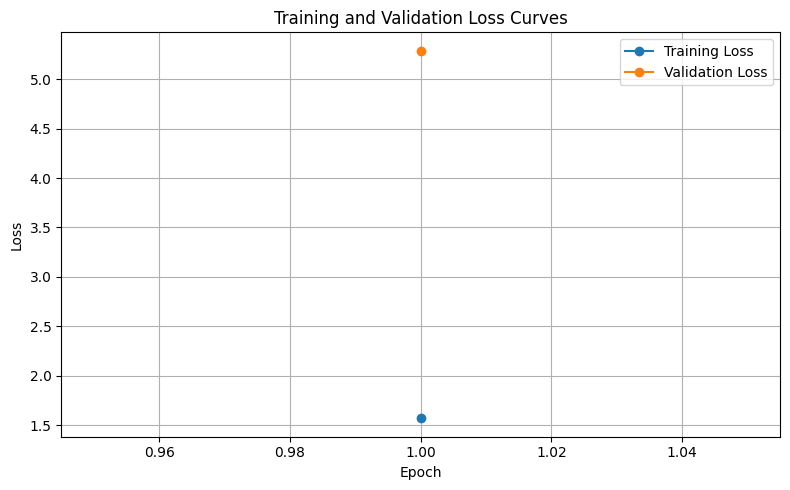

Saved: artifacts/figures/training_curves.png


In [28]:
# Plot and save training/validation loss curves

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training and Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

training_curves_path = figures_dir / "training_curves.png"
plt.savefig(training_curves_path, dpi=150)
plt.show()

print("Saved:", training_curves_path)

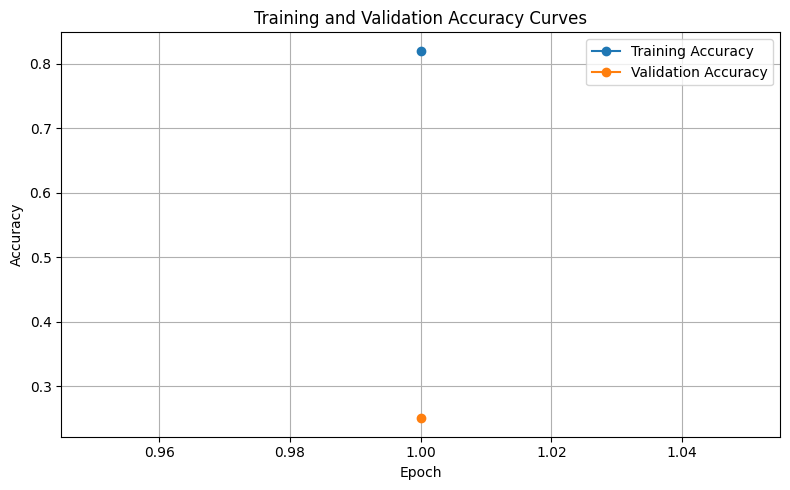

Saved: artifacts/figures/accuracy_curves.png


In [29]:
# Plot and save training/validation accuracy curves

epochs = range(1, len(history["train_accuracy"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training and Validation Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_curves_path = figures_dir / "accuracy_curves.png"
plt.savefig(accuracy_curves_path, dpi=150)
plt.show()

print("Saved:", accuracy_curves_path)

In [30]:
# Final test evaluation using best checkpoint

model.load_state_dict(torch.load(best_checkpoint_path, map_location=device))

test_loss, test_acc, test_precision, test_recall, test_f1, test_roc_auc = evaluate(
    model, test_loader, criterion, device
)

test_metrics = {
    "test_loss": test_loss,
    "test_accuracy": test_acc,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
    "test_roc_auc": test_roc_auc,
    "fast_dev_run": FAST_DEV_RUN,
}

test_metrics_df = pd.DataFrame([test_metrics])
test_metrics_path = reports_dir / "test_metrics.csv"
test_metrics_df.to_csv(test_metrics_path, index=False)

test_metrics_df

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,fast_dev_run
0,1.713454,0.59375,0.0,0.0,0.0,NaN,True


In [31]:
# Final output check

required_outputs = [
    best_checkpoint_path,
    last_checkpoint_path,
    history_csv_path,
    training_curves_path,
    accuracy_curves_path,
    test_metrics_path,
]

for path in required_outputs:
    print(path, "exists:", path.exists())

print("\nNotebook completed successfully.")

artifacts/checkpoints/best_model.pt exists: True
artifacts/checkpoints/last_model.pt exists: True
artifacts/logs/training_history.csv exists: True
artifacts/figures/training_curves.png exists: True
artifacts/figures/accuracy_curves.png exists: True
artifacts/reports/test_metrics.csv exists: True

Notebook completed successfully.
